<a href="https://colab.research.google.com/github/dherreraal/object_oriented_programming/blob/main/Clase_09/09_POO_CicloFor_Recursividad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estructuras Cíclicas (for) y Funciones Recursivas
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez
#### **Curso:** Programación Orientada a Objetos (POO)
---

## Índice de Contenido
1. Introducción: De `while` a `for`
2. La estructura de control de ciclos `for`
3. El ciclo `for` como iterador de colecciones
4. Ciclos Anidados: Un `for` dentro de otro `for`
5. Introducción a las Funciones Recursivas
6. La Pila de Llamadas (Call Stack) y el Error de StackOverflow
7. Iteración vs. Recursividad
8. Ejercicios Prácticos
9. Bibliografía y Referencias
---

## 1. Introducción: De `while` a `for`
En clases anteriores, conocimos el ciclo `while` (mientras), que repite un bloque de código mientras una condición sea verdadera. Para que un `while` no se vuelva infinito, normalmente seguimos este patrón de 3 pasos:
1. **Inicializamos** una variable contador (ej. `int i = 0;`).
2. **Evaluamos** una condición lógica usando ese contador (ej. `while (i < 5)`).
3. **Actualizamos** el contador al final del ciclo (ej. `i++;`).

Tener estas tres piezas separadas en diferentes líneas puede hacer que el código sea largo y que olvidemos el paso 3 (creando un ciclo infinito catastrófico).
El ciclo `for` nació para **compactar** este patrón. Nos obliga a poner la inicialización, la condición y la actualización juntas en una sola línea, haciendo el código más limpio, fácil de leer y menos propenso a errores.

## 2. La estructura de control de ciclos `for`

El ciclo `for` (para) es una estructura cíclica de uso frecuente en programación. Su principal uso es iterar cuando **sabemos de antemano cuántas veces queremos repetir algo**.

### Sintaxis detallada del ciclo `for`
```java
for (inicialización; condición_de_parada; actualización) {
    // Bloque de código a repetir (Cuerpo del ciclo)
}
```

**¿Cómo funciona paso a paso?**
1. La **inicialización** se ejecuta *una sola vez* al arrancar el ciclo.
2. Se evalúa la **condición_de_parada**. Si es `true`, entra al ciclo. Si es `false`, el ciclo termina.
3. Se ejecuta el **cuerpo del ciclo** (las instrucciones adentro de las llaves `{}`).
4. Se ejecuta la **actualización** (generalmente incrementa o decrementa el contador).
5. Vuelve al paso 2.

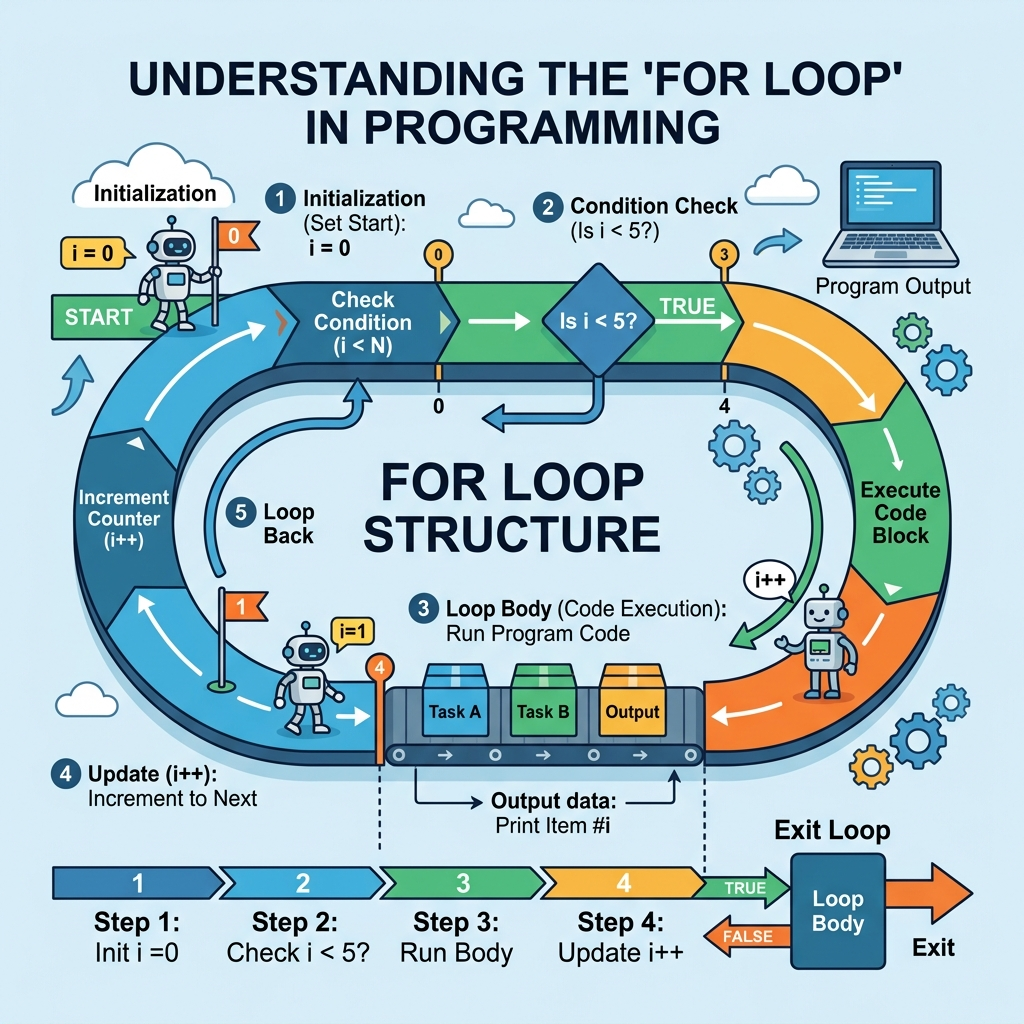
<p style="text-align: center; font-style: italic;">Figura 1: Representación conceptual del ciclo for, mostrando la pista por donde viaja la información.</p>

Veamos un ejemplo práctico: imprimir los números del 1 al 5.

In [1]:
%%writefile EjemploFor.java
public class EjemploFor {
    public static void main(String[] args) {
        System.out.println("Contando con un ciclo for:");

        // Inicialización: int i = 1 (empieza en 1)
        // Condición: i <= 5 (repite mientras sea menor o igual a 5)
        // Actualización: i++ (suma 1 en cada vuelta)
        for (int i = 1; i <= 5; i++) {
            System.out.println("El valor de i es: " + i);
        }
        System.out.println("¡Ciclo terminado!");
    }
}

Writing EjemploFor.java


In [2]:
!java EjemploFor.java

[0.025s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.025s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Contando con un ciclo for:
El valor de i es: 1
El valor de i es: 2
El valor de i es: 3
El valor de i es: 4
El valor de i es: 5
¡Ciclo terminado!


## 3. El ciclo `for` como iterador de colecciones (for-each)
A veces no nos importan los números (0, 1, 2...), sino los **elementos de una colección** (como un arreglo de textos). Para esos casos, Java (y muchos lenguajes modernos) ofrecen una versión simplificada llamada **"enhanced for loop" (o for-each)**.

Su sintaxis se lee como: *"Por cada (for) elemento del tipo X en la colección Y, haz esto..."*. Es más directo porque no necesitamos manejar un índice `i`.

In [3]:
%%writefile EjemploForEach.java
public class EjemploForEach {
    public static void main(String[] args) {
        // Un arreglo de cadenas de texto (Strings)
        String[] inventario = {"Espada", "Escudo", "Poción de Vida", "Mapa"};

        System.out.println("Tus objetos en el inventario son:");

        // Ciclo for-each
        // Se lee: "Por cada String al que llamaré 'objeto' en el arreglo 'inventario'"
        for (String objeto : inventario) {
            System.out.println("- " + objeto);
        }
    }
}

Writing EjemploForEach.java


In [4]:
!java EjemploForEach.java

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Tus objetos en el inventario son:
- Espada
- Escudo
- Poción de Vida
- Mapa


## 4. Ciclos Anidados: Un `for` dentro de otro `for`
En muchas ocasiones, necesitamos repetir una acción que *ya es repetitiva*. Para esto usamos **ciclos anidados** (un ciclo dentro de otro ciclo).

Esto es indispensable para trabajar con datos en dos dimensiones (como matrices, tableros de ajedrez o imágenes).
**Regla de oro:** Por cada *una* iteración del ciclo externo, el ciclo interno se ejecuta *por completo*.

Veamos cómo imprimir una matriz o rectángulo de asteriscos:

In [5]:
%%writefile EjemploAnidado.java
public class EjemploAnidado {
    public static void main(String[] args) {
        int filas = 3;
        int columnas = 5;

        // Ciclo externo: avanza fila por fila
        for (int i = 1; i <= filas; i++) {
            System.out.print("Fila " + i + ": ");

            // Ciclo interno: imprime las columnas de ESA fila específica
            for (int j = 1; j <= columnas; j++) {
                System.out.print("* ");
            }
            // Salto de línea al terminar la fila
            System.out.println();
        }
    }
}

Writing EjemploAnidado.java


In [6]:
!java EjemploAnidado.java

[0.002s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.002s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Fila 1: * * * * * 
Fila 2: * * * * * 
Fila 3: * * * * * 


## 5. Introducción a las Funciones Recursivas
La **recursividad** (descrita a profundidad en el Capítulo 8 del texto *Guide to Java*) es una técnica de programación donde **una función se llama a sí misma** para resolver un problema más pequeño.

Imagina que estás en una fila y quieres saber en qué posición estás, pero no puedes ver el inicio. Le preguntas a la persona de adelante: *"¿En qué posición estás tú?"*. Esa persona tampoco lo sabe, así que le pregunta a la de adelante... y así sucesivamente, hasta llegar a la primera persona en la fila, quien responde *"Soy el 1"*. Esa respuesta se devuelve hacia atrás hasta llegar a ti.

Para que la función no se llame infinitamente, **siempre** debe tener:
1. **El Caso Base:** La condición más simple que sabemos resolver inmediatamente. Aquí la función *deja de llamarse a sí misma* (ej. llegar al 1 de la fila).
2. **El Paso Recursivo:** La función hace un poco de trabajo y se llama a sí misma enviando un problema un poco más pequeño.

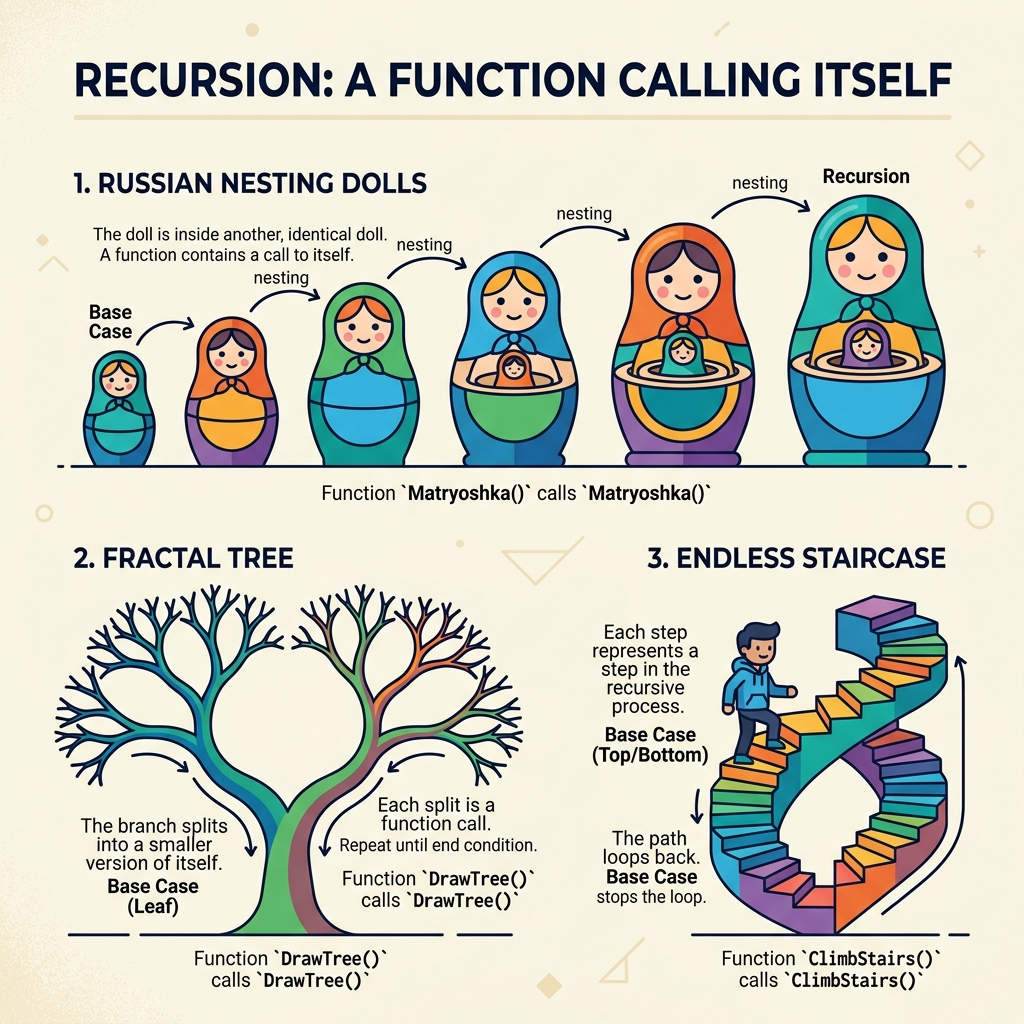
<p style="text-align: center; font-style: italic;">Figura 2: La recursividad funciona como las muñecas rusas o una escalera sin fin que debe tener una condición de parada (caso base).</p>

### Ejemplo matemático: El Factorial
El factorial de un número $N$ ($N!$) es la multiplicación de todos los enteros desde 1 hasta $N$.
Ej: $4! = 4 \times 3 \times 2 \times 1$.

Visto de forma recursiva, $4!$ es igual a $4 \times 3!$.
El **Caso Base** es cuando $N = 1$ (porque sabemos que $1! = 1$).

In [7]:
%%writefile EjemploFactorial.java
public class EjemploFactorial {

    // Función recursiva
    public static int calcularFactorial(int n) {
        // 1. CASO BASE: Si llegamos a 1, retornamos 1 inmediatamente.
        if (n == 1) {
            System.out.println("Caso base alcanzado: n=1, devuelvo 1");
            return 1;
        }
        // 2. PASO RECURSIVO: n multiplicado por el factorial de (n-1)
        System.out.println("Calculando " + n + " * factorial(" + (n-1) + ")");
        int resultado = n * calcularFactorial(n - 1);
        System.out.println("Retornando resultado de " + n + "! = " + resultado);
        return resultado;
    }

    public static void main(String[] args) {
        int numero = 4;
        System.out.println("--- INICIANDO CALCULO DE " + numero + "! ---");
        int total = calcularFactorial(numero);
        System.out.println("El resultado final es: " + total);
    }
}

Writing EjemploFactorial.java


In [8]:
!java EjemploFactorial.java

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
--- INICIANDO CALCULO DE 4! ---
Calculando 4 * factorial(3)
Calculando 3 * factorial(2)
Calculando 2 * factorial(1)
Caso base alcanzado: n=1, devuelvo 1
Retornando resultado de 2! = 2
Retornando resultado de 3! = 6
Retornando resultado de 4! = 24
El resultado final es: 24


## 6. La Pila de Llamadas (Call Stack) y el Error de StackOverflow
¿Por qué es tan importante el Caso Base?

Cuando un programa se ejecuta, la computadora utiliza una zona de memoria llamada **Pila de Llamadas (Call Stack)**, que funciona como una pila de platos. Cada vez que llamas a una función, la computadora pone un "plato" nuevo en la pila para recordar los datos de esa función. Cuando la función termina, el plato se retira.

En la recursividad, como la función llama a otra función y a otra antes de terminar la primera, ¡los platos se empiezan a acumular!
Si no hay un Caso Base, se acumularán platos infinitamente hasta que la memoria del sistema colapse. Esto produce el temido **`StackOverflowError`** (Error de desbordamiento de pila).

In [9]:
%%writefile EjemploPila.java
public class EjemploPila {

    // Función recursiva intencionalmente SIN caso base
    public static void funcionInfinita(int contador) {
        System.out.println("Plato en la pila número: " + contador);
        // ¡No hay condición de parada! Se llamará infinitamente.
        funcionInfinita(contador + 1);
    }

    public static void main(String[] args) {
        System.out.println("Preparando el colapso de la memoria...");
        // Si quitas los '//' de la siguiente línea y ejecutas, verás el StackOverflowError:
        // funcionInfinita(1);
        System.out.println("La llamada infinita está comentada para proteger la memoria.");
    }
}

Writing EjemploPila.java


In [10]:
!java EjemploPila.java

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Preparando el colapso de la memoria...
La llamada infinita está comentada para proteger la memoria.


## 7. Iteración vs. Recursividad
Cualquier problema que resuelvas de forma recursiva, matemáticamente puede ser resuelto con ciclos (iteración), y viceversa.

*   **Iteración (Ciclos):** Son más rápidos y eficientes en memoria. No acumulan "platos" en la Pila de Llamadas.
*   **Recursividad:** Hace que tu código sea sumamente elegante, conciso y fácil de leer para resolver problemas complejos que tienen una naturaleza jerárquica (como carpetas dentro de carpetas en tu sistema operativo, o grafos/árboles en inteligencia artificial).

Un buen programador elige la herramienta adecuada según la situación.

## 8. Ejercicios Prácticos

A continuación encontrarás dos ejercicios. Completa el código en la **Casilla de Plantilla** y luego corre la **Casilla de Ejecución** para probar tu solución.

---

### Ejercicio 1: Sumatoria Iterativa
**Enunciado:** Escribe un programa que utilice un ciclo `for` para sumar todos los números impares desde el 1 hasta el 20, y luego imprima el resultado final.

In [11]:
%%writefile Ejercicio1.java
public class Ejercicio1 {
    public static void main(String[] args) {
        int sumaImpares = 0;

        // TU CÓDIGO AQUÍ:
        // Crea un ciclo for que vaya del 1 al 20, verifica si es impar, y súmalo.


        System.out.println("La suma total de impares es: " + sumaImpares);
    }
}

Writing Ejercicio1.java


In [12]:
!java Ejercicio1.java

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
La suma total de impares es: 0


---
### Ejercicio 2: Conteo Regresivo Recursivo
**Enunciado:** Crea un método recursivo llamado `cuentaRegresiva` que reciba un número $N$. Debe imprimir los números en orden descendente hasta llegar a cero (por ejemplo: 3, 2, 1, 0). Cuando llegue a cero (tu caso base), imprime "¡Despegue!" y termina la recursión.

In [13]:
%%writefile Ejercicio2.java
public class Ejercicio2 {

    public static void cuentaRegresiva(int n) {
        // 1. TU CASO BASE AQUÍ
        if (/* Condición de parada */) {
            // Imprime ¡Despegue! y retorna
        }
        // 2. TU PASO RECURSIVO AQUÍ
        // Imprime el valor actual de n, y vuelve a llamar al método reduciendo n

    }

    public static void main(String[] args) {
        System.out.println("Iniciando cuenta regresiva desde 5...");
        cuentaRegresiva(5);
    }
}

Writing Ejercicio2.java


In [14]:
!java Ejercicio2.java

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Ejercicio2.java:5: error: illegal start of expression
        if (/* Condición de parada */) {
                                     ^
1 error
error: compilation failed


---
### Ejercicio 3: Triángulo con Ciclos Anidados
**Enunciado:** Utiliza ciclos `for` anidados para imprimir un triángulo rectángulo hecho de asteriscos (`*`). La base y altura del triángulo estarán dadas por la variable `n`.
Por ejemplo, si `n = 4`, la salida en consola debe ser:
```
*
**
***
****
```

In [15]:
%%writefile Ejercicio3.java
public class Ejercicio3 {
    public static void main(String[] args) {
        int n = 5; // Altura y base del triángulo

        // TU CÓDIGO AQUÍ:
        // Un ciclo for externo (filas) y un ciclo for interno (columnas)

    }
}

Writing Ejercicio3.java


In [16]:
!java Ejercicio3.java

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate


---
### Ejercicio 4: Potencia Recursiva
**Enunciado:** Escribe un método recursivo llamado `potencia` que reciba dos enteros: una `base` y un `exponente`. El método debe calcular la potencia sin usar ciclos `for` o `while` (es decir, calculando la potencia mediante multiplicación recursiva).
Recuerda que cualquier número elevado a la 0 es 1 (Este será tu **caso base**).

In [17]:
%%writefile Ejercicio4.java
public class Ejercicio4 {

    public static int potencia(int base, int exponente) {
        // TU CÓDIGO AQUÍ:
        // 1. Caso Base: Si el exponente es 0, retorna 1.

        // 2. Paso Recursivo: Retorna base multiplicada por la llamada recursiva (con exponente - 1).
        return 0; // Cambia esto
    }

    public static void main(String[] args) {
        int b = 2;
        int e = 3;
        // El resultado debe ser 8
        System.out.println(b + " elevado a la " + e + " es: " + potencia(b, e));
    }
}

Writing Ejercicio4.java


In [18]:
!java Ejercicio4.java

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
2 elevado a la 3 es: 0


## 9. Bibliografía y Referencias
- **León, G., Rodríguez, A., Gómez, J., Cubides, C. & Sierra, C.A.** Estructuras cíclicas II (Diapositivas de clase). Universidad Nacional de Colombia.
- **Streib, J. T., & Soma, T. (2014).** Guide to Java: A Concise Introduction to Programming. Springer. (Capítulo 4: Iteration Structures, Capítulo 8: Recursion).
- **Oracle Java Documentation:** [The for Statement](https://docs.oracle.com/javase/tutorial/java/nutsandbolts/for.html)